In [66]:
import pandas as pd 
import numpy as np

In [ ]:
# Load data
df = pd.read_excel("../data/data.xlsx")
df.head()

,Cube_ID,Mix_ID,Steel_Fibre_%,Cube_Size,Age_Days,Curing_Method,Failure_Load_kN,Compressive_Strength_MPa
0,1,UHPC-5,2.0,100x100x100 mm,28,Steam Curing,2046.7,204.67
1,2,UHPC-5,2.0,100x100x100 mm,90,Steam Curing,2286.7,228.67
2,3,UHPC-5,2.0,100x100x100 mm,90,Heat Curing,2364.6,236.46
3,4,UHPC-5,2.0,100x100x100 mm,28,Heat Curing,2061.0,206.10
4,5,UHPC-1,0.0,100x100x100 mm,28,Heat Curing,1919.8,191.98


In [ ]:
# REMOVE USELESS COLUMNS
df = df.drop(columns=[
    "Cube_ID",
    "Cube_Size",
    "Compressive_Strength_MPa"
])

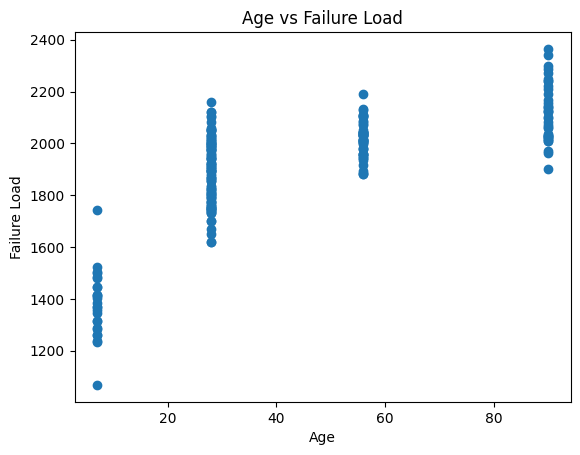

In [69]:
# Age vs Failure Load 
import matplotlib.pyplot as plt
plt.scatter(df["Age_Days"], df["Failure_Load_kN"]) 
plt.xlabel("Age") 
plt.ylabel("Failure Load") 
plt.title("Age vs Failure Load") 
plt.show()

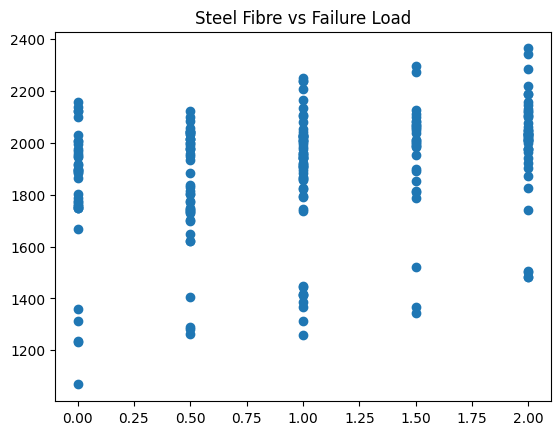

In [ ]:
# Steel Fibre vs Load 
plt.scatter(df["Steel_Fibre_%"], df["Failure_Load_kN"]) 
plt.title("Steel Fibre vs Failure Load") 
plt.show()

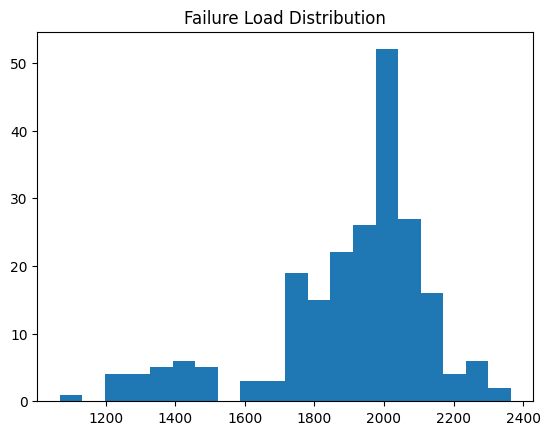

In [71]:
# Distribution 
plt.hist(df["Failure_Load_kN"], bins=20) 
plt.title("Failure Load Distribution") 
plt.show()

In [72]:
print(list(df.columns))

['Mix_ID', 'Steel_Fibre_%', 'Age_Days', 'Curing_Method', 'Failure_Load_kN']


In [73]:
# Clean column 
df.columns = df.columns.str.strip() 

In [ ]:
# Feature engineering
df["Fibre_Age"] = df["Steel_Fibre_%"] * df["Age_Days"] 
df["Log_Age"] = np.log1p(df["Age_Days"])

In [ ]:
# Split
from sklearn.model_selection import train_test_split 

X = df.drop("Failure_Load_kN", axis=1) 
y = df["Failure_Load_kN"] 

# Encoding
X = pd.get_dummies(X) 
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

In [76]:
from xgboost import XGBRegressor 

model = XGBRegressor( n_estimators=400, learning_rate=0.03, max_depth=3, random_state=42 )

In [ ]:
# Train model
model.fit(X_train, y_train) 
from sklearn.metrics import r2_score 

# Test model
y_pred = model.predict(X_test) 

# Evaluate model
print("R2:", r2_score(y_test, y_pred))

R2: 0.920647192503828


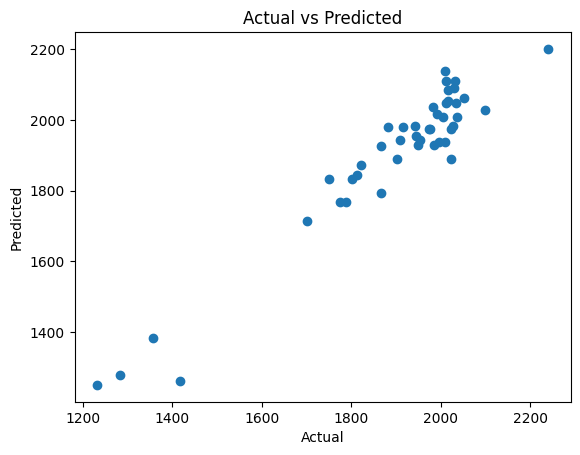

In [ ]:
# visual prediction
plt.scatter(y_test, y_pred) 
plt.xlabel("Actual") 
plt.ylabel("Predicted") 
plt.title("Actual vs Predicted") 
plt.show()

In [ ]:
# Manual Check
print("Test 1:", model.predict(X_test.iloc[[0]])) 
print("Test 2:", model.predict(X_test.iloc[[5]])) 
print("Test 3:", model.predict(X_test.iloc[[10]])) 
print("Test 4:", model.predict(X_test.iloc[[20]]))

Test 1: [1842.9122]
Test 2: [1279.3933]
Test 3: [2089.801]
Test 4: [1936.2224]


In [ ]:
# Saving model
import joblib 

joblib.dump(model, "../model/model.pkl") 
joblib.dump(X.columns, "../model/columns.pkl")


['../model/columns.pkl']